In [ ]:
%load_ext autoreload
%matplotlib widget

from helper_funcs import *
from collections import defaultdict
import numpy as np
import pandas as pd


dirs = get_dirs(root=r"c:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")
dpi = 500

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Get data
def get_data(T_xi_types, cgram=False):
    data = defaultdict(lambda: defaultdict(dict))

    for T_xi_type in T_xi_types:
        # Read df
        df = pd.read_excel(os.path.join(
            dirs["results"], rf"soae_T_xi [{T_xi_type}].xlsx"
        ))

        dfs = {}
        dfs["P"] = df[df["mode"]=="P"]
        dfs["phi"] = df[df["mode"]=="phi"]
        
        # Gather everything into lists


        for mode in ["phi", "P"]:
            for prop in ["T_xi", "f0_max", "f0_fit", "species", "wf_idx"]:
                data[T_xi_type][mode][prop] = np.array(dfs[mode][prop])
            # Calculate derived data
            data[T_xi_type][mode]["N_xi"] = data[T_xi_type][mode]["T_xi"] * data[T_xi_type][mode]["f0_max"]
            data[T_xi_type][mode]["inv_T_xi"] = 1/(data[T_xi_type][mode]["T_xi"])
        data[T_xi_type]["T_xi_diffs"] = data[T_xi_type]["P"]["T_xi"] - data[T_xi_type]["phi"]["T_xi"]
        data[T_xi_type]["N_xi_diffs"] = data[T_xi_type]["P"]["N_xi"] - data[T_xi_type]["phi"]["N_xi"]

        if cgram:
            dfs["cgram"] = pd.read_excel(os.path.join(dirs["results"], f"soae_T_xi_cgram [{T_xi_type}, T_xi_thresh={T_xi_thresh}, fmin={fmin}, hpf_cf={hpf_cf}].xlsx"))

            # Ditto for cgram
            for prop in ["T_xi", "f0", "species", "wf_idx"]:
                data[T_xi_type]["cgram"][prop] = np.array(dfs["cgram"][prop])
            data[T_xi_type]["cgram"]["N_xi"] = data[T_xi_type]["cgram"]["T_xi"] * data[T_xi_type]["cgram"]["f0"]
            data[T_xi_type]["cgram"]["inv_T_xi"] = 1/(data[T_xi_type]["cgram"]["T_xi"])

    return data

dict_keys(['int 25ms', 'int 500ms'])


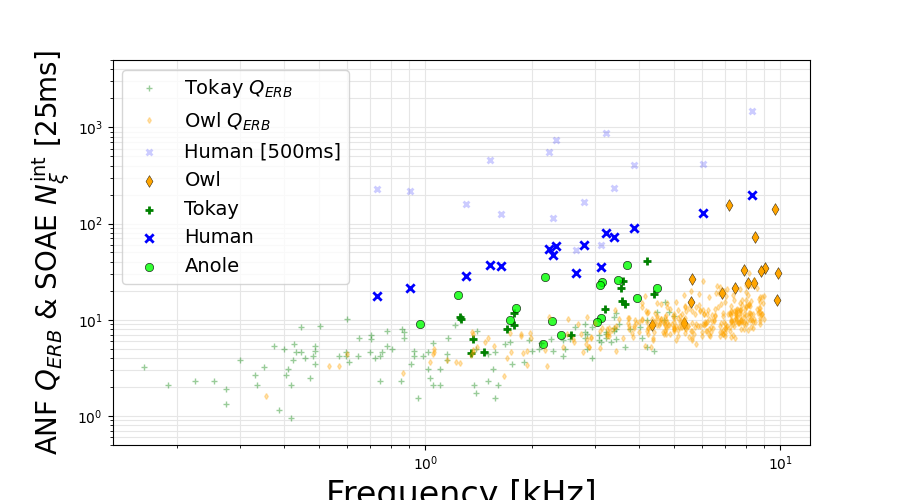

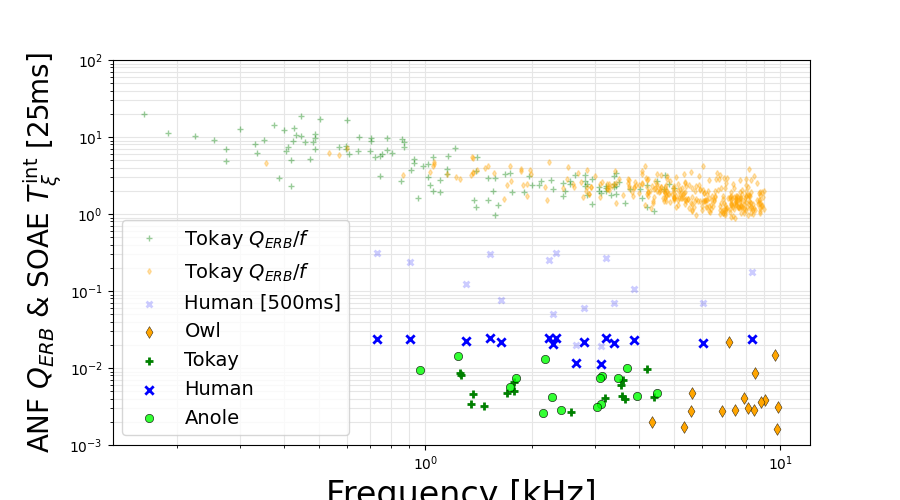

In [6]:
"Qerb and N_xi vs Freq"
int_time_short = "int 25ms"
int_time_long = "int 500ms"

data = get_data((int_time_short, int_time_long))
fig_fp_id = f"int {int_time_short[4:]} ({int_time_long[4:]} Human)"

print(data.keys())

alpha_human_long = 0.2
s_human_long = 18

for tc in ["N_xi", "T_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{fig_fp_id}].jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
    
    # Plot Q_ERB
    plt.plot(
        freqANFtokay,
        QerbANFtokay,
        "+",
        color="green",
        alpha=0.4,
        ms=4,
        lw=1,
        markerfacecolor="green",
        label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    plt.plot(
        freqANFowl,
        QerbANFowl,
        "d",
        color="orange",
        alpha=0.3,
        ms=3,
        lw=1,
        markerfacecolor="orange",
        label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    # Plot Human
    human_mask = [sp == "Human" for sp in data[int_time_long]["phi"]["species"]]
    plt.scatter(
            (data[int_time_long]["phi"]["f0_max"] / 1000)[human_mask],
            data[int_time_long]["phi"][tc][human_mask],
            marker=markers["Human"],
            color=colors["Human"],
            lw=mews["Human"],
            alpha=alpha_human_long,
            s=s_human_long,
            facecolors=mfcs["Human"],
            label=f"Human [{int_time_long[4:]}]",
        )


    # Plot X_xis
    for s in set(data[int_time_short]["phi"]["species"]):
        mask = [sp == s for sp in data[int_time_short]["phi"]["species"]]

        plt.scatter(
            (data[int_time_short]["phi"]["f0_max"] / 1000)[mask],
            data[int_time_short]["phi"][tc][mask],
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            label=s,
        )
    




    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(0.5, 5e3)
    elif tc=="T_xi":
        plt.ylim(1e-3, 1e2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"ANF $Q_{{ERB}}$ & SOAE ${tc[0]}_\xi^\text{{int}}$ [{int_time_short[4:]}]", fontsize=fsz-4)
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

In [ ]:
"Old"
# Qerb vs N_xi
for T_xi_type in ["int 50ms", "int 100ms", "int 500ms"]:
    data = get_data(T_xi_type, cgram=False)

    "Qerb and X_xi vs Freq"
    for tc in ["N_xi", "T_xi"]:

        # ======================================================
        fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{T_xi_type}].jpg")


        # --- owl ANF tuning curve data (Excel files provided by Christine)
        fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
        fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
        # ======================================================


        # --- read in data
        owlANF = pd.read_excel(fp_ANFfileOwl)
        toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

        # =========================
        # deal w/ owl ANF vals
        owlANF = owlANF[1:]  # discard first line
        freqANFowl = owlANF["CF"].values
        QerbANFowl = owlANF["Qerb"].values

        # =========================
        # deal w/ tokay ANF vals
        freqANFtokay = toakyANFq10[:, 0]
        QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
        # convert to Qerb(?) via Bergevin & Shera 2010

        if tc == "T_xi":
            QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

        # =======================================================================
        # ==== visualize
        plt.close("all")
        # ------------------------------------------------
        plt.figure(figsize=(9, 5))
        plt.grid(True, which="both", ls="-", color="0.9")
        alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
        markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
        colors = {"Anole": "k", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        mews = {"Anole": 0.5, "Owl": 2, "Human": 2, "Tokay": 2}
        mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        # Plot
        for s in set(data[T_xi_type]["phi"]["species"]):
            mask = [sp == s for sp in data[T_xi_type]["phi"]["species"]]

            plt.scatter(
                (data[T_xi_type]["phi"]["f0_max"] / 1000)[mask],
                data[T_xi_type]["phi"][tc][mask],
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas[s],
                s=36,
                facecolors=mfcs[s],
                label=s,
            )


        # Plot Q_ERB
        plt.plot(
            freqANFtokay,
            QerbANFtokay,
            "+",
            color="green",
            alpha=0.4,
            ms=4,
            lw=1,
            markerfacecolor="green",
            label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
        )

        plt.plot(
            freqANFowl,
            QerbANFowl,
            "d",
            color="orange",
            alpha=0.3,
            ms=3,
            lw=1,
            markerfacecolor="orange",
            label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
        )

        # ---
        fsz=24
        plt.xscale("log")
        plt.yscale("log")
        # plt.xlim([0.1, 12])
        if tc=="N_xi":
            plt.ylim(0.5, 5e3)
        elif tc=="T_xi":
            plt.ylim(1e-3, 1e2)
        plt.xlabel("Frequency [kHz]", fontsize=fsz)
        plt.ylabel(rf"SOAE ${tc[0]}_\xi^{{{T_xi_type}}}$ & ANF $Q_{{ERB}}$", fontsize=fsz)
        plt.legend(fontsize=fsz-10)

        plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
        plt.show()


# Qerb and X_xi vs Freq - CGRAM
for tc in ["N_xi"]:
    for T_xi_type in ["int"]:
        data = get_data(T_xi_type, cgram=False)
    
        # ======================================================
        fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq - CGRAM [{T_xi_type}, T_xi_thresh={T_xi_thresh}, fmin={fmin}, hpf_cf={hpf_cf}].jpg")


        # --- owl ANF tuning curve data (Excel files provided by Christine)
        fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
        fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
        # ======================================================


        # --- read in data
        owlANF = pd.read_excel(fp_ANFfileOwl)
        toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

        # =========================
        # deal w/ owl ANF vals
        owlANF = owlANF[1:]  # discard first line
        freqANFowl = owlANF["CF"].values
        QerbANFowl = owlANF["Qerb"].values

        # =========================
        # deal w/ tokay ANF vals
        freqANFtokay = toakyANFq10[:, 0]
        QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
        # convert to Qerb(?) via Bergevin & Shera 2010

        # =======================================================================
        # ==== visualize
        plt.close("all")
        # ------------------------------------------------
        plt.figure(figsize=(9, 5))
        alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
        markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
        colors = {"Anole": "k", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        mews = {"Anole": 0.5, "Owl": 2, "Human": 2, "Tokay": 2}
        mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
        # Plot
        for s in set(data[T_xi_type]["cgram"]["species"]):
            mask = [sp == s for sp in data[T_xi_type]["cgram"]["species"]]

            plt.scatter(
                (data[T_xi_type]["cgram"]["f0"] / 1000)[mask],
                data[T_xi_type]["cgram"][tc][mask],
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas[s],
                s=36,
                facecolors=mfcs[s],
                label=s,
            )


        # Plot Q_ERB
        plt.plot(
            freqANFtokay,
            QerbANFtokay,
            "+",
            color="green",
            alpha=0.4,
            ms=4,
            lw=1,
            markerfacecolor="green",
            label=r"Tokay $Q_{ERB}$",
        )

        plt.plot(
            freqANFowl,
            QerbANFowl,
            "d",
            color="orange",
            alpha=0.3,
            ms=3,
            lw=1,
            markerfacecolor="orange",
            label=r"Owl $Q_{ERB}$",
        )

        # ---
        fsz=24
        plt.xscale("log")
        plt.yscale("log")
        # plt.xlim([0.1, 12])
        # plt.ylim([0.8,2000])
        plt.xlabel("Frequency [kHz]", fontsize=fsz)
        plt.ylabel(rf"SOAE ${tc[0]}_\xi^{{{T_xi_type}}}$ & ANF $Q_{{ERB}}$", fontsize=fsz)
        plt.title(rf"${tc[0]}_\xi$ Spectrum")
        plt.grid(True, which="both", ls="-", color="0.9")
        # plt.legend(fontsize=fsz-10)
        
        plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
        plt.show()